<a href="https://colab.research.google.com/github/DimDragg/-/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Модель «хижак – жертва». Чуркін Дмитро ФІТ 3-15

Був присутній на парі

Завдання:
1. Побудувати діаграму накопичувачів і потоків для моделі «хижак – жертва».
2. Побудувати комп’ютерну модель «хижак – жертва» на основі системної динаміки.
3. Визначити умови стабільного співіснування жертв і хижаків та запустити модель за цих початкових умов.
4. Дослідити як зміна ефективності полювання впливає на чисельність хижаків і жертв.
5. Зробити коефіцієнт народжуваності жертв залежним від сезонності.
6. Додати до моделі ємність середовища, здійснити дослідження за різних його значень.

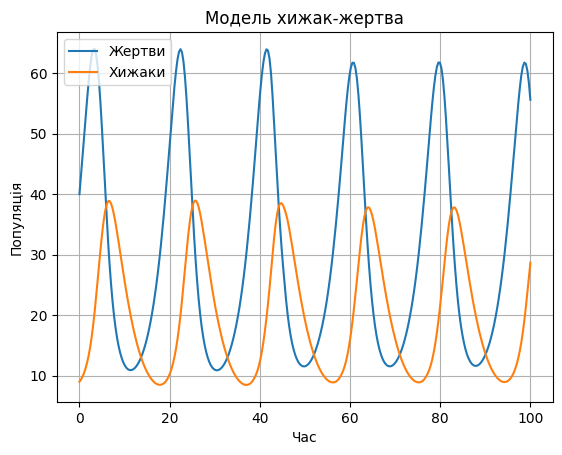

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Параметри
gamma = 0.5   # народжуваність жертв
delta = 0.1   # смертність жертв
alpha = 0.02  # ефективність полювання
beta = 0.01   # розмноження хижаків
sigma = 0.3   # смертність хижаків

# Модель
def predator_prey(t, z):
    x, y = z
    dxdt = gamma*x - delta*x - alpha*x*y
    dydt = beta*x*y - sigma*y
    return [dxdt, dydt]

# Початкові умови
z0 = [40, 9]

# Час
t_span = (0, 100)
t_eval = np.linspace(0, 100, 300)

# Розв’язок
sol = solve_ivp(predator_prey, t_span, z0, t_eval=t_eval)

# Графік
plt.plot(sol.t, sol.y[0], label="Жертви")
plt.plot(sol.t, sol.y[1], label="Хижаки")
plt.legend()
plt.xlabel("Час")
plt.ylabel("Популяція")
plt.title("Модель хижак-жертва")
plt.grid()
plt.show()

def gamma_t(t):
    return 0.5 * (1 + 0.3 * np.sin(0.1 * t))

def predator_prey(t, z):
    x, y = z
    dxdt = gamma_t(t)*x - delta*x - alpha*x*y
    dydt = beta*x*y - sigma*y
    return [dxdt, dydt]

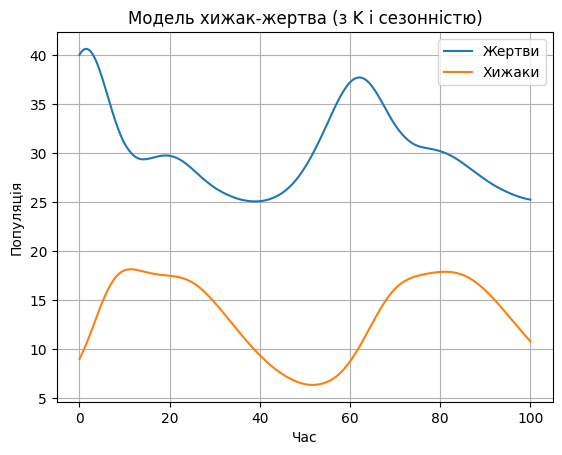

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Параметри
gamma = 0.5
delta = 0.1
alpha = 0.02
beta = 0.01
sigma = 0.3
K = 100  # Ємність середовища

# Сезонність
def gamma_t(t):
    return gamma * (1 + 0.3 * np.sin(0.1 * t))

# Модель
def predator_prey(t, z):
    x, y = z

    dxdt = gamma_t(t)*x*(1 - x/K) - delta*x - alpha*x*y
    dydt = beta*x*y - sigma*y

    return [dxdt, dydt]

# Початкові умови
z0 = [40, 9]

# Час
t_span = (0, 100)
t_eval = np.linspace(0, 100, 300)

# Розв’язок
sol = solve_ivp(predator_prey, t_span, z0, t_eval=t_eval)

# Графік
plt.plot(sol.t, sol.y[0], label="Жертви")
plt.plot(sol.t, sol.y[1], label="Хижаки")
plt.legend()
plt.xlabel("Час")
plt.ylabel("Популяція")
plt.title("Модель хижак-жертва (з K і сезонністю)")
plt.grid()
plt.show()